## Build [Disease, HAS_SYMPTOM, Symptom] triples

Reads `Final CSV.csv` (one disease per row, symptoms spread across `Symptom_1` ... `Symptom_17`) and flattens it into triples using nested for loops.

In [46]:
import csv
triples = []

with open("Final CSV.csv", newline="", encoding="utf-8-sig") as f:
    reader = csv.reader(f)
    header = next(reader)  # skip the header row

    # OUTER loop: one row per disease record
    for row in reader:
        if not row:
            continue

        disease = row[0].strip()
        if not disease:
            continue

        # INNER loop: every symptom column on that row
        for cell in row[1:]:
            symptom = cell.strip()
            if not symptom:
                continue

            triples.append([disease, "HAS_SYMPTOM", symptom])

print(f"Total triples: {len(triples)}")

# peek at the first 20
for triple in triples[:20]:
    print(triple)

# save them all out
with open("disease_symptom_triples.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["subject", "predicate", "object"])
    for triple in triples:
        writer.writerow(triple)

Total triples: 36648
['Fungal infection', 'HAS_SYMPTOM', 'itching']
['Fungal infection', 'HAS_SYMPTOM', 'skin_rash']
['Fungal infection', 'HAS_SYMPTOM', 'nodal_skin_eruptions']
['Fungal infection', 'HAS_SYMPTOM', 'dischromic _patches']
['Fungal infection', 'HAS_SYMPTOM', 'skin_rash']
['Fungal infection', 'HAS_SYMPTOM', 'nodal_skin_eruptions']
['Fungal infection', 'HAS_SYMPTOM', 'dischromic _patches']
['Fungal infection', 'HAS_SYMPTOM', 'itching']
['Fungal infection', 'HAS_SYMPTOM', 'nodal_skin_eruptions']
['Fungal infection', 'HAS_SYMPTOM', 'dischromic _patches']
['Fungal infection', 'HAS_SYMPTOM', 'itching']
['Fungal infection', 'HAS_SYMPTOM', 'skin_rash']
['Fungal infection', 'HAS_SYMPTOM', 'dischromic _patches']
['Fungal infection', 'HAS_SYMPTOM', 'itching']
['Fungal infection', 'HAS_SYMPTOM', 'skin_rash']
['Fungal infection', 'HAS_SYMPTOM', 'nodal_skin_eruptions']
['Fungal infection', 'HAS_SYMPTOM', 'skin_rash']
['Fungal infection', 'HAS_SYMPTOM', 'nodal_skin_eruptions']
['Fungal i

In [47]:
import networkx as nx

G = nx.DiGraph()

for subject, predicate, obj in triples:
    G.add_node(subject, kind="Disease")
    G.add_node(obj, kind="Symptom")
    G.add_edge(subject, obj, relation=predicate)

print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

sorted(G.predecessors('itching')) #shows the symptoms (Shows the 

sorted(G.successors('Jaundice'))

nodes: 172 edges: 321


['abdominal_pain',
 'dark_urine',
 'fatigue',
 'high_fever',
 'itching',
 'vomiting',
 'weight_loss',
 'yellowish_skin']

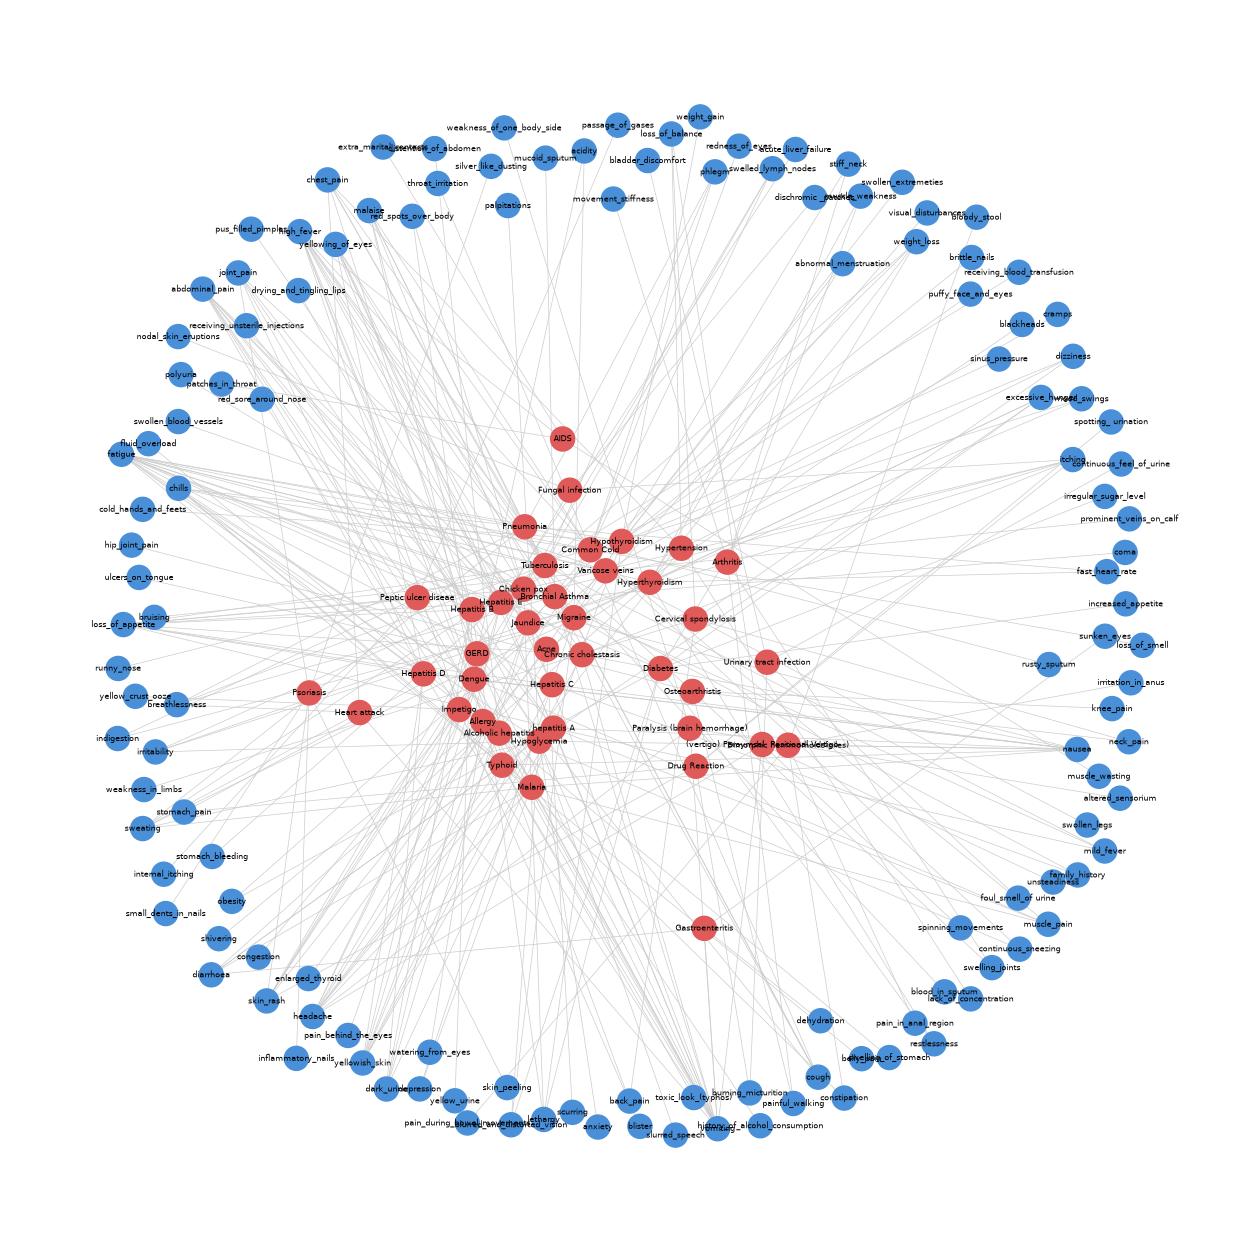

In [48]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(16, 16))
pos = nx.spring_layout(G, k=0.5, seed=42)

colors = ["#e05a5a" if G.nodes[n]["kind"] == "Disease" else "#4a90d9" for n in G]

nx.draw_networkx(G, pos, node_color=colors, node_size=300, font_size=6,
                 edge_color="#cccccc", arrows=False, width=0.5)
plt.axis("off")
plt.show()

In [49]:
# WEIGHTING: how "meaningful" is each symptom for identifying a disease

# weight(symptom) = (total number of diseases) / (number of diseases that have this symptom)

# Common symptom -> low weight (it's in "a lot" of diseases, so it doesn't mean much on its own).
# Niche symptom -> high weight (it's rare, so it's a strong signal).

# STEP 1: a set for every symptom of diseases it shows up in.
symptom_to_diseases = {}

for disease, predicate, symptom in triples: #predicate for the relationship between disease and symptom
    if symptom not in symptom_to_diseases:
        symptom_to_diseases[symptom] = set() #set ensure something cant be added twice 
    symptom_to_diseases[symptom].add(disease)

# STEP 2: total number of distinct diseases in the dataset.
all_diseases = set()
for disease, predicate, symptom in triples:
    all_diseases.add(disease)

total_diseases = len(all_diseases)
print(f"Total distinct diseases: {total_diseases}")
print(f"Total distinct symptoms: {len(symptom_to_diseases)}")

# STEP 3: turn each symptom's disease-count into a weight.
symptom_weight = {}

for symptom, diseases in symptom_to_diseases.items():
    diseases_with_this_symptom = len(diseases)
    weight = total_diseases / diseases_with_this_symptom
    symptom_weight[symptom] = weight

# STEP 4: sanity-check
symptom_weight_rounded = {symptom: round(weight) for symptom, weight in symptom_weight.items()}
print("\nSymptom weights:", symptom_weight_rounded)

# STEP 5: attach the weight to every triple.
weighted_triples = []
for disease, predicate, symptom in triples:
    weight = symptom_weight[symptom]
    weighted_triples.append([disease, predicate, symptom, weight])

# STEP 6: save the weighted triples to their own CSV.
with open("weighted_disease_symptom_triples.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["subject", "predicate", "object", "weight"])
    for row in weighted_triples:
        writer.writerow(row)

print(f"\nSaved {len(weighted_triples)} weighted triples to weighted_disease_symptom_triples.csv")


Total distinct diseases: 41
Total distinct symptoms: 131

Symptom weights: {'itching': 7, 'skin_rash': 6, 'nodal_skin_eruptions': 41, 'dischromic _patches': 41, 'continuous_sneezing': 20, 'shivering': 41, 'chills': 6, 'watering_from_eyes': 41, 'stomach_pain': 20, 'acidity': 20, 'ulcers_on_tongue': 41, 'vomiting': 2, 'cough': 8, 'chest_pain': 7, 'yellowish_skin': 5, 'nausea': 4, 'loss_of_appetite': 4, 'abdominal_pain': 5, 'yellowing_of_eyes': 6, 'burning_micturition': 20, 'spotting_ urination': 41, 'passage_of_gases': 41, 'internal_itching': 41, 'indigestion': 20, 'muscle_wasting': 41, 'patches_in_throat': 41, 'high_fever': 3, 'extra_marital_contacts': 41, 'fatigue': 2, 'weight_loss': 10, 'restlessness': 20, 'lethargy': 10, 'irregular_sugar_level': 41, 'blurred_and_distorted_vision': 14, 'obesity': 20, 'excessive_hunger': 10, 'increased_appetite': 41, 'polyuria': 41, 'sunken_eyes': 41, 'dehydration': 41, 'diarrhoea': 8, 'breathlessness': 10, 'family_history': 20, 'mucoid_sputum': 41, 'h

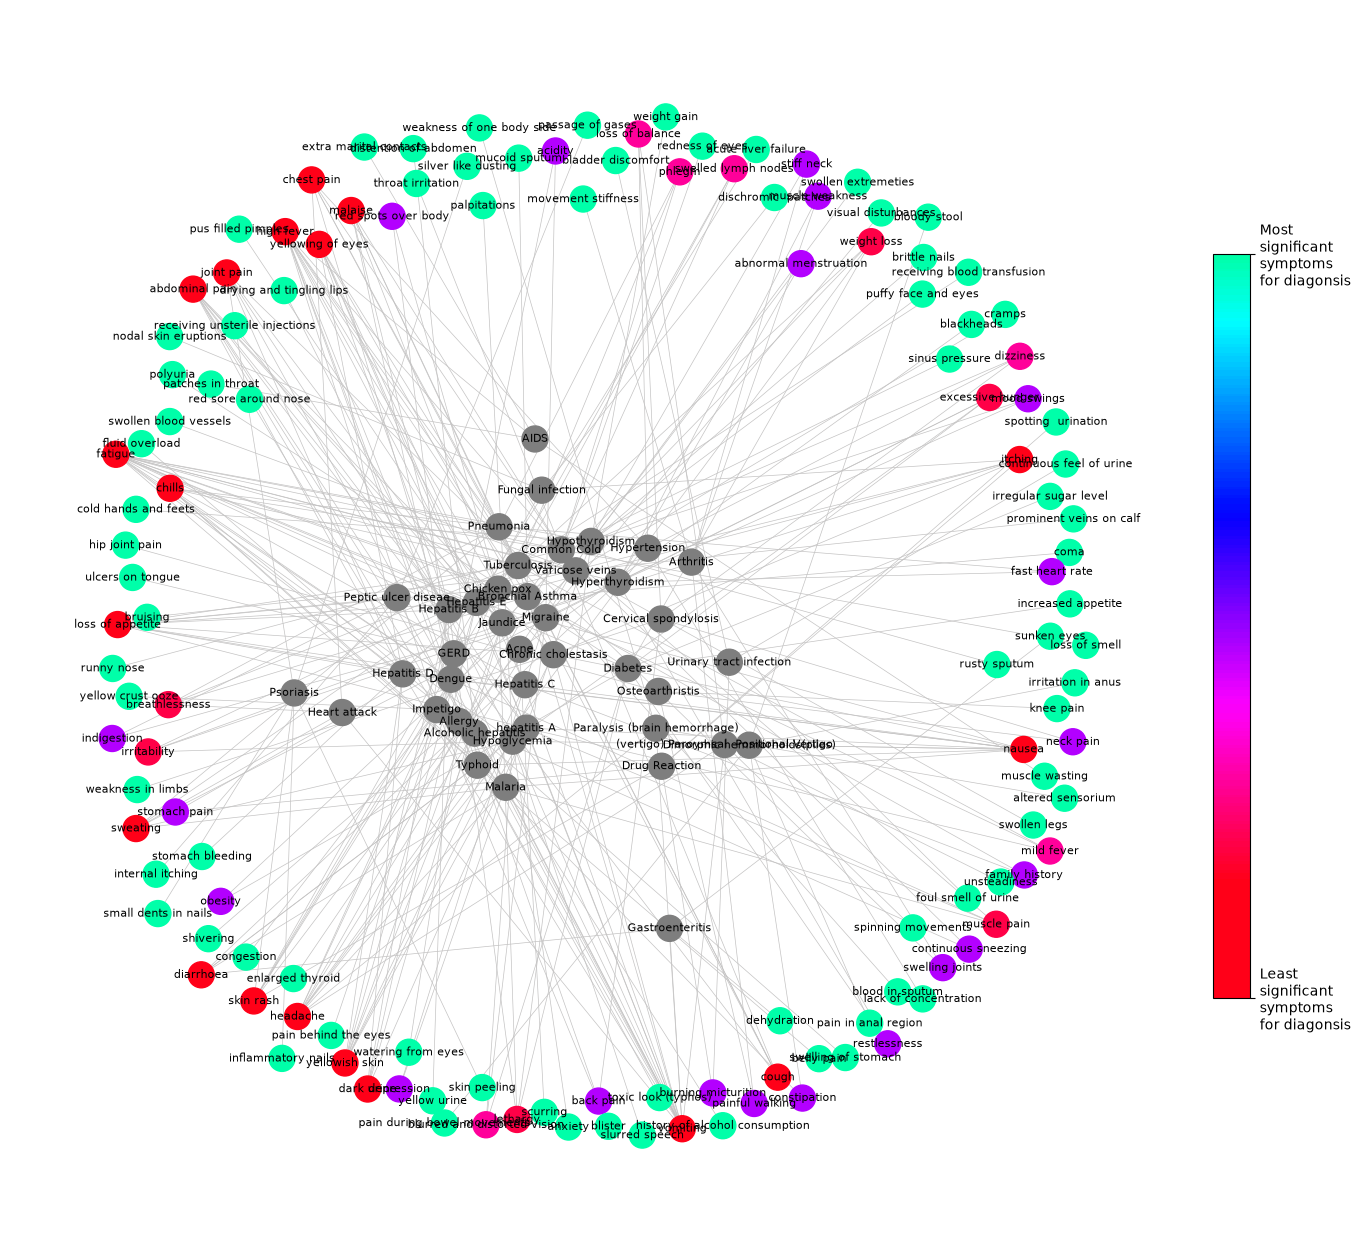

In [50]:
# Add Weights to the lines or colours? - code the more important symptoms the redder is is on a scale from blue to red - make the diseases grey
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.colors as mcolors
import numpy as np

norm = mcolors.Normalize(vmin=min(symptom_weight.values()), vmax=max(symptom_weight.values()))
hsv = plt.colormaps["hsv"]

start_frac = 1.1   
end_frac = 0.45

cmap = mcolors.LinearSegmentedColormap.from_list(
    "hsv_red_pink_purple_green", hsv(np.linspace(start_frac, end_frac, 256))
)

symptom_colour = {}
for symptom, weight in symptom_weight.items():
    symptom_colour[symptom] = cmap(norm(weight))

plt.figure(figsize=(16, 16))
pos = nx.spring_layout(G, k=0.5, seed=42)

colors = []
for n in G:
    if G.nodes[n]["kind"] == "Disease":
        colors.append("#7E7E7E")
    else:
        colors.append(symptom_colour[n])

labels = {n: n.replace("_", " ") for n in G} # formatting so theres no _

# --- COLOUR KEY ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_ticks([norm.vmin, norm.vmax])
cbar.set_ticklabels(["Least\nsignificant\nsymptoms\nfor diagonsis", "Most\nsignificant\nsymptoms\nfor diagonsis"])


nx.draw_networkx(G, pos, node_color=colors, node_size=350, font_size=8,
                 edge_color="#C4C3C3", arrows=False, width=0.5, labels=labels)


plt.axis("off")
plt.show()

In [ ]:
#Integrating the other dataset 
import csv
triples2 = []

with open("final_symptoms_to_disease.csv", newline="", encoding="utf-8-sig") as f:
    reader = csv.reader(f)
    header = next(reader)  # skip the header row

    # OUTER loop: one row per disease record
    for row in reader:
        disease = row[0].strip()
        symptom_text = row[1].strip()

        for cell in symptom_text.split(","):
            cell = cell.strip() #huh
            if not cell:
                continue

            words = cell.split(' ') # separating by spaces
            
            if 'and' in words or 'or' in words:
                current_words = []
                for word in words:
                    if word == "and" or word == "or":
                        # hit a joiner: bank what we've built up so far
                        if current_words:
                            triples2.append([disease, "HAS_SYMPTOM", ' '.join(current_words)])
                            current_words = []
                    else:
                        # normal word: keep building the symptom
                        current_words.append(word)
                # whatever's left after the last and/or still needs banking
                if current_words:
                    triples2.append([disease, "HAS_SYMPTOM", ' '.join(current_words)])
            else:
                # no and/or in this chunk, so the whole chunk is the symptom
                triples2.append([disease, "HAS_SYMPTOM", cell])
# seperate into spaces and then see if theres an and or and or or and then add the symptom to the list of symptoms for that disease - (nested if loops)
         

print(f"Total triples: {len(triples2)}")

# peek at the first 20
for triple in triples2[:20]:
    print(triple)

# save them all out
with open("disease_symptom_triples_2.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["subject", "predicate", "object"])
    for triple in triples2:
        writer.writerow(triple)


In [52]:
# LM studio (from chats)


# Neo4J (like networkx)

# AI FUNCTION